# QELM Tomography with Interacting Fermion Reservoir

The goal of this notebook is to begin experimenting with performing full quantum state tomography using an interacting fermion model for both the target and reservoir. Ideally, measurements will be restricted to site occupation measures, and the aim is to reproduce something similar to the model implemented on Equal1 chips

## 1. Imports

In [1]:
from qsim.dynamics import Dynamics, GKSLGenerator, RK4Propagator, IVPPropagator
from qsim.state import DensityMatrix, Detector
from qsim.lin_alg import Operator, sigmaMinus, sigmaPlus, I
from qsim.ensemble import HilbertSchmidt

from qres.qelm import QELM

import numpy as np
import scipy

from tqdm.auto import tqdm

## 2. Reservoir Configuration

In [2]:
n_target = 2
n_reservoir = 2

t_multi = 5

#On-site energy
e_min = -2
e_max = 2

# Tunneling strength
t_min = 0.5
t_max = 1.5

# Interaction strength
v_min = 0.5
v_max = 2.5

# Pairing Strength
delta_min = 0.2
delta_max = 0.8

# Damping strength
gamma_min = 0.1
gamma_max = 0.5

# Squeezing strength

s_min = 0.5
s_max = 1

In [3]:
from functools import reduce


def interactingFermion(n_target, n_reservoir):
    dim = n_target + n_reservoir
    
    ops = []

    for i in range(dim):
        ops.append((np.random.uniform(e_min, e_max) * sigmaPlus @ sigmaMinus).changeHilbertSpace(new_dims=(2,) * dim, send_to_sites = (i,)))
        ops.append((np.random.uniform(s_min, s_max) * (sigmaPlus + sigmaMinus)).changeHilbertSpace(new_dims=(2,) * dim, send_to_sites = (i,)))
    
    for i in range(dim):
        for j in range(i):
            sigma_plus_i = sigmaPlus.changeHilbertSpace((2,)*dim, (i,))
            sigma_minus_i = sigmaMinus.changeHilbertSpace((2,)*dim, (i,))
            sigma_plus_j = sigmaPlus.changeHilbertSpace((2,)*dim, (j,))
            sigma_minus_j = sigmaMinus.changeHilbertSpace((2,)*dim, (j,))
            n_i = sigma_plus_i @ sigma_minus_i
            n_j = sigma_plus_j @ sigma_minus_j

            ops.append(np.random.uniform(t_min, t_max) * (sigma_minus_i @ sigma_plus_j + sigma_minus_j @ sigma_plus_i))
            ops.append(np.random.uniform(v_min, v_max) * n_i @ n_j)
            ops.append(np.random.uniform(delta_min, delta_max) * (sigma_plus_i @ sigma_plus_j + sigma_minus_i @ sigma_minus_j))

    return reduce(lambda x,y : x+y, ops)

def interactingFermionSquareLattice(n_target, n_reservoir, W):
    dim = n_target + n_reservoir
    
    ops = []

    for i in range(dim):
        ops.append((np.random.uniform(e_min, e_max) * sigmaPlus @ sigmaMinus).changeHilbertSpace(new_dims=(2,) * dim, send_to_sites = (i,)))
        ops.append((np.random.uniform(s_min, s_max) * (sigmaPlus + sigmaMinus)).changeHilbertSpace(new_dims=(2,) * dim, send_to_sites = (i,)))
    
    for i in range(dim):
        for j in range(i):
            x_i, y_i = i % W, i // W
            x_j, y_j = j % W, j // W 

            if abs(x_i - x_j) + abs(y_i - y_j) == 1:
                print(f'Coupling node {i} to node {j}')
                sigma_plus_i = sigmaPlus.changeHilbertSpace((2,)*dim, (i,))
                sigma_minus_i = sigmaMinus.changeHilbertSpace((2,)*dim, (i,))
                sigma_plus_j = sigmaPlus.changeHilbertSpace((2,)*dim, (j,))
                sigma_minus_j = sigmaMinus.changeHilbertSpace((2,)*dim, (j,))
                n_i = sigma_plus_i @ sigma_minus_i
                n_j = sigma_plus_j @ sigma_minus_j

                ops.append(np.random.uniform(t_min, t_max) * (sigma_minus_i @ sigma_plus_j + sigma_minus_j @ sigma_plus_i))
                ops.append(np.random.uniform(v_min, v_max) * n_i @ n_j)
                ops.append(np.random.uniform(delta_min, delta_max) * (sigma_plus_i @ sigma_plus_j + sigma_minus_i @ sigma_minus_j))

    return reduce(lambda x,y : x+y, ops)

def interactingFermionChain(n_target, n_reservoir):
    dim = n_target + n_reservoir
    
    ops = []

    for i in range(dim):
        ops.append((np.random.uniform(e_min, e_max) * sigmaPlus @ sigmaMinus).changeHilbertSpace(new_dims=(2,) * dim, send_to_sites = (i,)))
        ops.append((np.random.uniform(s_min, s_max) * (sigmaPlus + sigmaMinus)).changeHilbertSpace(new_dims=(2,) * dim, send_to_sites = (i,)))
    
    for i in range(dim):
        for j in range(i):
            if i == j+1:
                print(f'Coupling node {i} to node {j}')
                sigma_plus_i = sigmaPlus.changeHilbertSpace((2,)*dim, (i,))
                sigma_minus_i = sigmaMinus.changeHilbertSpace((2,)*dim, (i,))
                sigma_plus_j = sigmaPlus.changeHilbertSpace((2,)*dim, (j,))
                sigma_minus_j = sigmaMinus.changeHilbertSpace((2,)*dim, (j,))
                n_i = sigma_plus_i @ sigma_minus_i
                n_j = sigma_plus_j @ sigma_minus_j

                ops.append(np.random.uniform(t_min, t_max) * (sigma_minus_i @ sigma_plus_j + sigma_minus_j @ sigma_plus_i))
                ops.append(np.random.uniform(v_min, v_max) * n_i @ n_j)
                ops.append(np.random.uniform(delta_min, delta_max) * (sigma_plus_i @ sigma_plus_j + sigma_minus_i @ sigma_minus_j))

    return reduce(lambda x,y : x+y, ops)

In [4]:
H = interactingFermionChain(n_target, n_reservoir)

Coupling node 1 to node 0
Coupling node 2 to node 1
Coupling node 3 to node 2


In [5]:

joint = False
gen = GKSLGenerator(H, jumps=[0.1 * sigmaMinus.changeHilbertSpace((2,)*(n_target + n_reservoir), send_to_sites=(i,)) for i in range(n_target + n_reservoir)])
prop = IVPPropagator()
dynam = Dynamics(prop, gen)
t=5
detectors = []
for i in range(n_target + n_reservoir):
    detectors.append(Detector(sigmaPlus @ sigmaMinus, dims=(2,) * (n_target + n_reservoir), target_sites=(i,)))
    for j in range(i):
        if joint:
            n_i = (sigmaPlus @ sigmaMinus).changeHilbertSpace((2,2), (0,))
            n_j = (sigmaPlus @ sigmaMinus).changeHilbertSpace((2,2), (1,))
            detectors.append(Detector(n_i + n_j, dims=(2,) * (n_target + n_reservoir), target_sites=(i,j)))
measures = [(sigmaPlus @ sigmaMinus).changeHilbertSpace((2,) * (n_target + n_reservoir), (i,)) for i in range(n_target + n_reservoir)]

def res_func_noise(shots=-1):
    def reservoir_func(state: DensityMatrix) -> np.ndarray[float]:
        res_state = np.zeros(shape=(2**(n_reservoir),)*2)
        res_state[0][0] = 1
        total_state = state ^ DensityMatrix(res_state)
        measures = []
        for i in range(t_multi):
            total_state = dynam.evolve(total_state, ts = [t])
            for d in detectors:
                measures.append(d.detect(total_state, shots))
        return np.array(measures)
    return reservoir_func

def heisenberg_func(ops: list[Operator]) -> list[Operator]:
    res_state = np.zeros(shape=(2**(n_reservoir),)*2)
    res_state[0][0] = 1
    total_state = I(2**n_target) ^ Operator(res_state)

    evolved_ops = []

    for i in range(t_multi):
        ops = [dynam.evolveOperator(op, ts = [0], t0 = t) for op in ops]
        for op in ops:
            evolved_ops.append((op @ total_state).partialTrace((2,)*(n_target + n_reservoir), tuple([i for i in range(n_target)])))

    return evolved_ops


## 3. Training Dataset

In [6]:
import numpy as np

def density_matrix_to_vec(rho: np.ndarray) -> np.ndarray:
    """
    Flatten a Hermitian density matrix into a 1D real vector containing
    all unique real and imaginary parts.

    Layout of the returned vector:
        [ diag (N),
          Re(upper off-diagonal) (N*(N-1)/2),
          Im(upper off-diagonal) (N*(N-1)/2) ]

    Parameters
    ----------
    rho : np.ndarray, shape (N, N), complex
        Hermitian density matrix.

    Returns
    -------
    vec : np.ndarray, shape (N**2,), float
        Flattened representation.
    """
    rho = np.asarray(rho)
    if rho.ndim != 2 or rho.shape[0] != rho.shape[1]:
        raise ValueError("rho must be a square 2D array")

    N = rho.shape[0]

    # Optional sanity check for Hermiticity
    if not np.allclose(rho, rho.conj().T):
        raise ValueError("rho is not Hermitian within numerical tolerance")

    # Diagonal (purely real for a density matrix)
    diag = rho.diagonal().real

    # Upper-triangular off-diagonal entries
    iu = np.triu_indices(N, k=1)
    upper = rho[iu]
    real_upper = upper.real
    imag_upper = upper.imag

    # Concatenate into a single real vector
    vec = np.concatenate([diag, real_upper, imag_upper]).astype(float)
    return vec


def vec_to_density_matrix(vec: np.ndarray) -> np.ndarray:
    """
    Reconstruct a Hermitian matrix from the flattened real vector produced
    by `density_matrix_to_vec`.

    Parameters
    ----------
    vec : np.ndarray, shape (N**2,), float
        Flattened representation.

    Returns
    -------
    rho : np.ndarray, shape (N, N), complex
        Reconstructed Hermitian matrix.
    """
    vec = np.asarray(vec, dtype=float).ravel()

    # Infer dimension N from length N**2
    N_float = np.sqrt(vec.size)
    N = int(round(N_float))
    if N * N != vec.size:
        raise ValueError("Length of vec must be a perfect square (N**2).")

    # Number of unique off-diagonal entries in the upper triangle
    K = N * (N - 1) // 2
    expected_len = N + 2 * K
    if vec.size != expected_len:
        raise ValueError(
            f"Invalid vector length {vec.size} for any Hermitian N; "
            f"expected N + 2 * N*(N-1)/2 = N**2."
        )

    # Slice out components
    diag = vec[:N]
    real_upper = vec[N:N + K]
    imag_upper = vec[N + K:]

    # Build matrix
    rho = np.zeros((N, N), dtype=complex)
    np.fill_diagonal(rho, diag)

    iu = np.triu_indices(N, k=1)
    rho[iu] = real_upper + 1j * imag_upper
    # Fill lower triangle by Hermitian symmetry
    rho[(iu[1], iu[0])] = rho[iu].conj()

    return rho



In [7]:
import numpy as np

def generalized_gell_mann(d):
    """Generate SU(d) generators (Gell-Mann matrices)."""
    lambdas = []

    # Symmetric generators
    for i in range(d):
        for j in range(i+1, d):
            mat = np.zeros((d, d), dtype=complex)
            mat[i, j] = 1
            mat[j, i] = 1
            lambdas.append(mat)

    # Antisymmetric generators
    for i in range(d):
        for j in range(i+1, d):
            mat = np.zeros((d, d), dtype=complex)
            mat[i, j] = -1j
            mat[j, i] = 1j
            lambdas.append(mat)

    # Diagonal generators
    for k in range(1, d):
        mat = np.zeros((d, d), dtype=complex)
        for i in range(k):
            mat[i, i] = 1
        mat[k, k] = -k
        mat = mat * np.sqrt(2 / (k * (k + 1)))
        lambdas.append(mat)

    return lambdas


def density_to_bloch(rho):
    """Convert density matrix to Bloch vector."""
    d = rho.shape[0]
    lambdas = generalized_gell_mann(d)

    r = np.zeros(len(lambdas), dtype=float)

    for i, lam in enumerate(lambdas):
        r[i] = 0.5 * np.trace(rho @ lam).real

    return r

def bloch_to_density(r):
    d = int(np.sqrt(len(r) + 1))
    lambdas = generalized_gell_mann(d)

    rho = np.eye(d, dtype=complex) / d

    for i, lam in enumerate(lambdas):
        rho += r[i] * lam

    return rho

def generate_x_training_set(n, n_thermal):
    num = int(np.ceil(np.sqrt(n))) - n_thermal
    thetas = np.linspace(0,1, num+1)[:-1] * 2 * np.pi
    states = [DensityMatrix(bloch_to_density(np.array([0,0,t]))) for t in np.linspace(0,1, n_thermal)]
    for theta in thetas:
        bloch_vec = np.array([np.sin(theta)/(2**0.5), np.sin(theta)/(2**0.5), np.cos(theta)])/2
        state = bloch_to_density(bloch_vec)
        states.append(DensityMatrix(state))

    tensor_states = []
    for s1 in states:
        for s2 in states:
            tensor_states.append(s1.tensor(s2))

    return  np.random.choice(tensor_states, size=n, replace=False)

def generate_x_training_set2(n):

    states = []
    for i in range(n):
        state1 = np.random.rand(2)
        state2 = np.random.rand(2)
        state1 /= np.sqrt(np.sum(state1**2))
        state2 /= np.sqrt(np.sum(state2**2))
        state1 = DensityMatrix(np.outer(state1, state1))
        state2 = DensityMatrix(np.outer(state2, state2))
        states.append(state1.tensor(state2))
    return states

def generate_x_training_set3(n):

    states = []
    for i in range(n):
        state1 = HilbertSchmidt.generateDM(2)
        state2 = HilbertSchmidt.generateDM(2)
        states.append(state1.tensor(state2))
    return states

def generate_x_training_set4():

    states = [DensityMatrix(bloch_to_density(np.array([0,0,1/2]))),DensityMatrix(bloch_to_density(np.array([0,1/2,0]))),DensityMatrix(bloch_to_density(np.array([1/2,0,0]))),DensityMatrix(bloch_to_density(np.array([0,0,-1/2])))]
    states2 = [DensityMatrix(bloch_to_density(np.array([-1/2,0,0]))),DensityMatrix(bloch_to_density(np.array([0,-1/2,0])))]
    ten_states = []
    for s1 in states:
        for s2 in states:
            ten_states.append(s1.tensor(s2))

    for s1 in states:
        for s2 in states2:
            ten_states.append(s1.tensor(s2))

    for s1 in states2:
        for s2 in states:
            ten_states.append(s1.tensor(s2))

    for s1 in states2:
        for s2 in states2:
            ten_states.append(s1.tensor(s2))
    return ten_states

In [8]:
n_train = 100
n_test = 100

x_train = HilbertSchmidt.generateDMBatch(2**(n_target), n=n_train)
x_train = generate_x_training_set4()[:16]
x_test = HilbertSchmidt.generateDMBatch(2**(n_target), n=n_test)

y_train = np.array([density_matrix_to_vec(x.matrix) for x in x_train])
y_test = np.array([density_matrix_to_vec(x.matrix) for x in x_test])

In [9]:
len(x_train)

16

## 4. Transform

In [13]:
qelm = QELM(res_func_noise(10**6), heisenberg_func)

In [14]:
qelm.fit(tqdm(x_train), y_train)

  0%|          | 0/16 [00:00<?, ?it/s]

In [15]:
score_mat = qelm.score(tqdm(x_test), y_test)

  0%|          | 0/100 [00:00<?, ?it/s]

In [16]:
score_mat

array([1.23035032e-05, 2.14678908e-05, 1.76938138e-05, 5.61983724e-06,
       4.02205879e-06, 2.03078386e-06, 9.91195016e-06, 4.64134576e-06,
       6.36740660e-06, 1.22467271e-05, 2.10251164e-06, 6.74269920e-06,
       1.22939250e-05, 6.67372057e-06, 3.08038267e-06, 1.20411740e-05])

In [17]:
evolved_ops = qelm.mapOperators(measures)

/Users/matthewmackinnon/Documents/repos/QRes/.venv/lib/python3.12/site-packages/scipy/integrate/_ivp/base.py:24: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(fun(t, y), dtype=dtype)


In [18]:
eff_ops = qelm.generateEffectiveOperators(measures)

In [19]:
def cov(op1, op2, state):
    return 0.5 * np.trace((op1 @ op2 - op2 @ op1) @ state) - np.trace(op1 @ state) * np.trace(op2 @ state)

def var(op, state):
    return np.trace(op @ op @ state) - np.trace(op @ state) ** 2

def max_var(op):
    vals = np.linalg.eigvals(op).real
    return (max(vals) - min(vals))**2/4

def ave_var(op):
    d = op.shape[0]
    return (1/(d*2 + d))*(d*np.trace(op @ op) - np.trace(op)**2)

In [20]:
covs = []

for i in range(len(evolved_ops)):
    for j in range(i):
        covs.append(cov(evolved_ops[i].matrix, evolved_ops[j].matrix, x_test[3].matrix))

In [21]:
np.mean(covs)

np.complex128(-0.08616280742338792+0j)

In [22]:
np.mean(qelm._reg.coeff[:,0]**2)

np.float64(1.6068857465028277)

In [23]:
sum([co**2 * ave_var(op.matrix) for co, op in zip(qelm._reg.coeff[:,0], evolved_ops)])

np.float64(5.767520613716287)

In [24]:
max_var(eff_ops[0].matrix)

np.float64(1.5473749224849713)

In [25]:
g = generalized_gell_mann(4)[0]

In [26]:
var(g, x_test[0].matrix)

np.complex128(0.44055978138058505+0j)

In [27]:
np.trace(g @ x_test[0].matrix)

np.complex128(-0.11835540360459403+0j)

In [28]:
var(g/10, x_test[0].matrix)

np.complex128(0.0044055978138058515+0j)

In [29]:
10 * np.trace(g/10 @ x_test[0].matrix)

np.complex128(-0.11835540360459404+0j)

In [30]:
np.trace(g @ g.T)**2 / 16

np.complex128(0.25+0j)

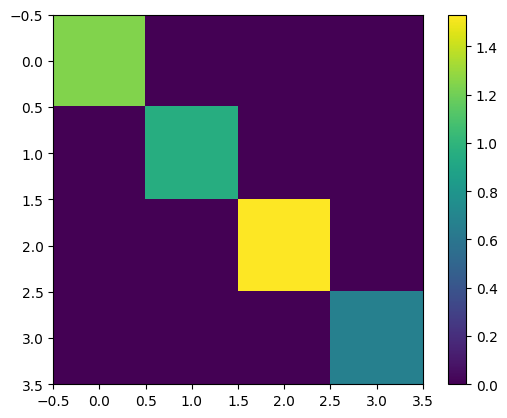

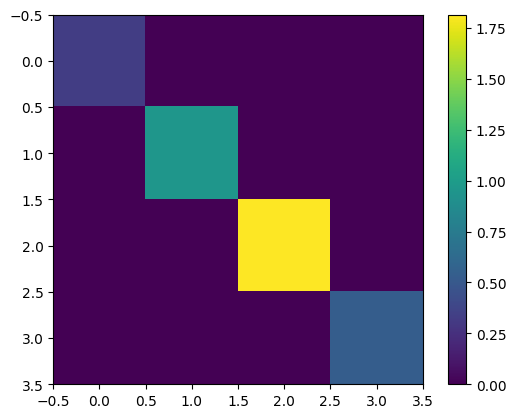

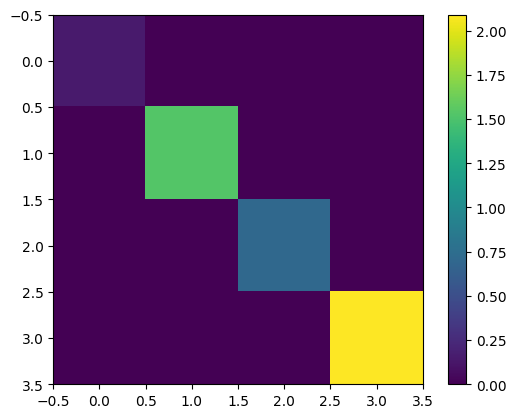

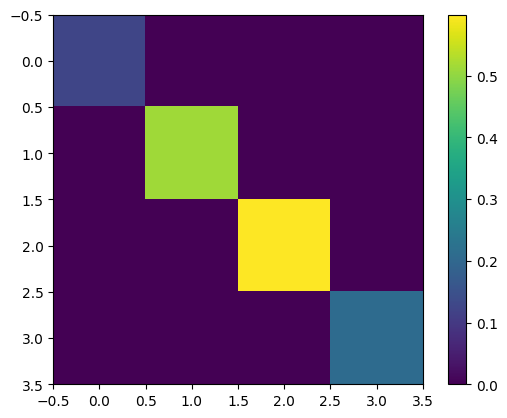

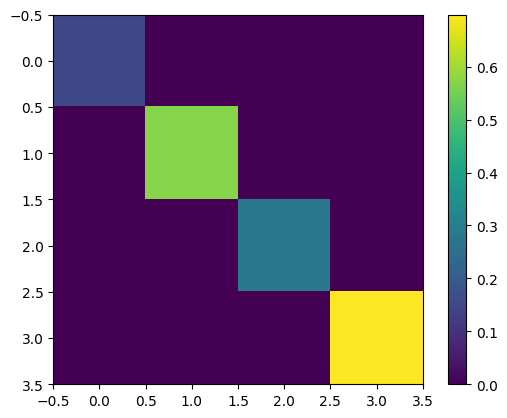

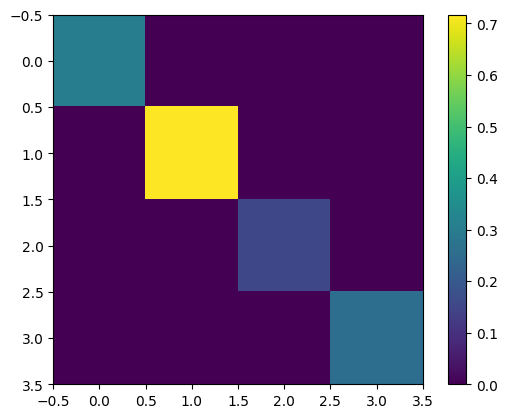

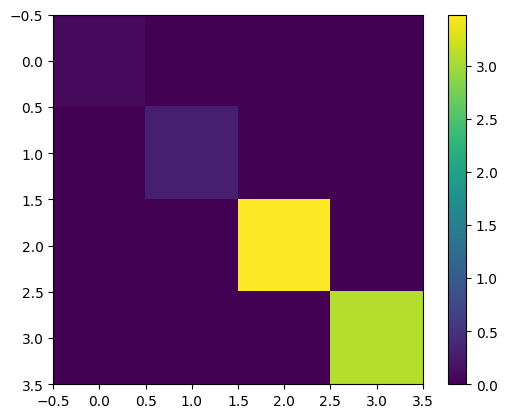

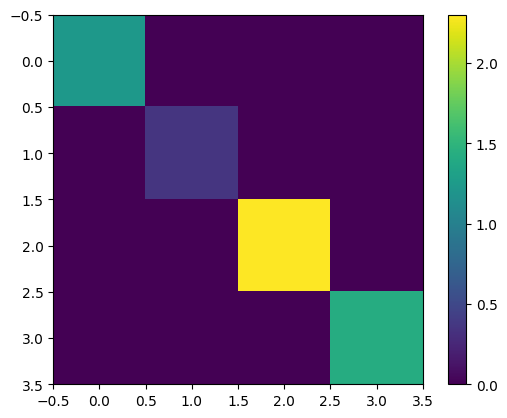

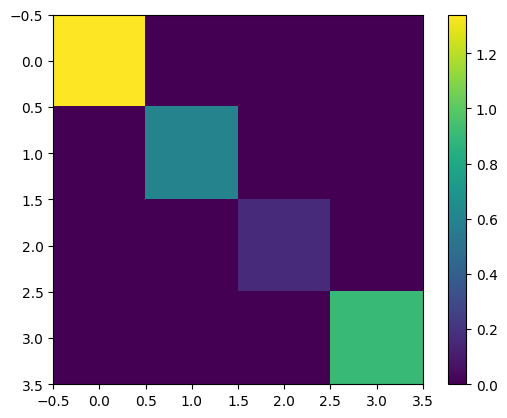

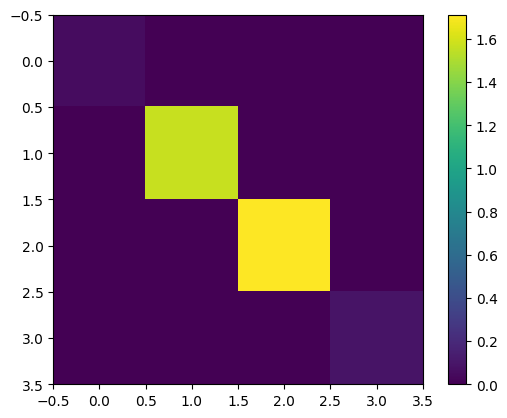

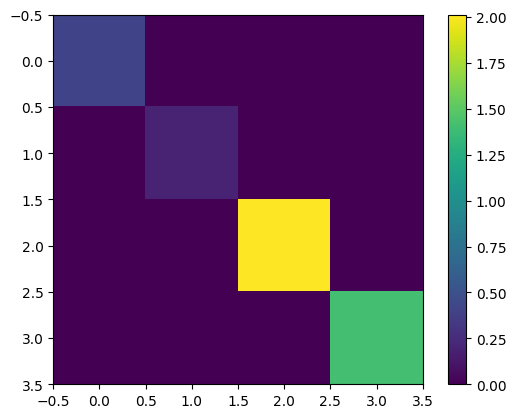

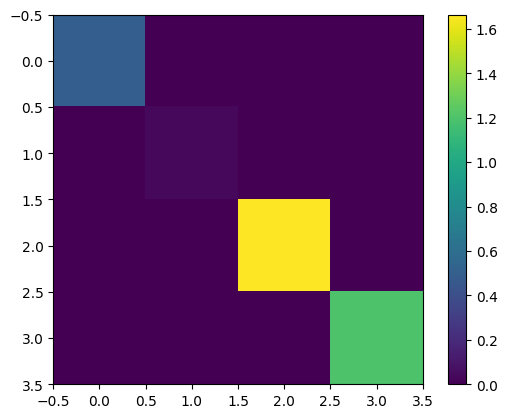

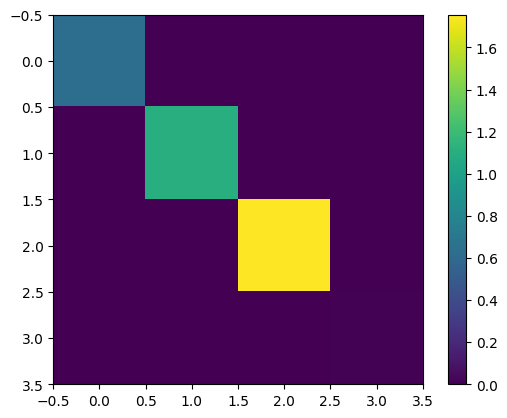

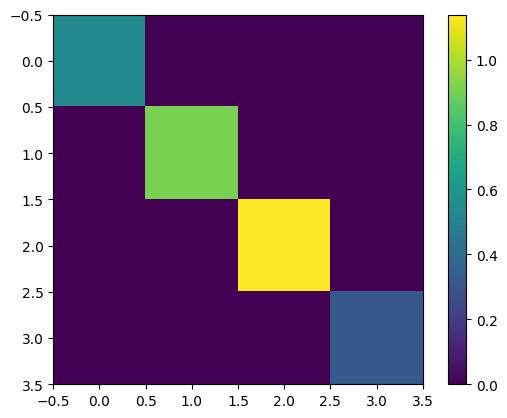

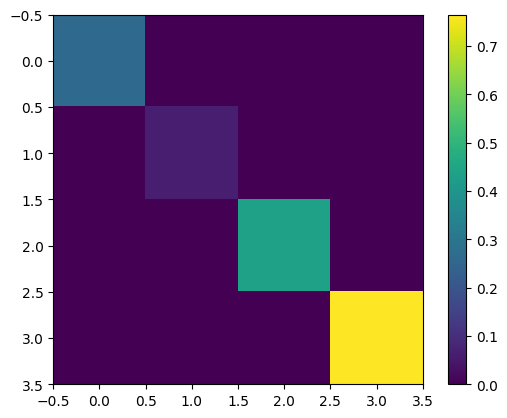

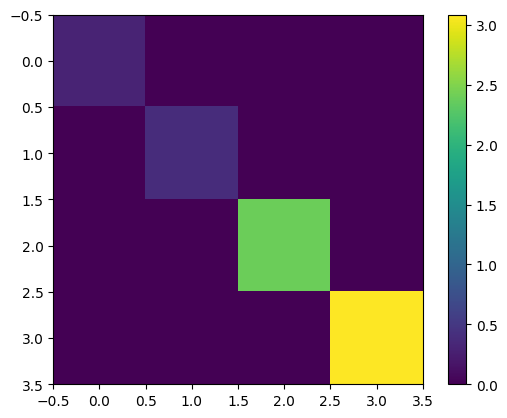

In [31]:
import matplotlib.pyplot as plt
for op in eff_ops:
    plt.figure()
    plt.imshow((np.abs(op.matrix)))
    plt.colorbar()

## 5. Perf vs noise and training data size

In [38]:
n_test = 50

x_train = HilbertSchmidt.generateDMBatch(2**(n_target), n=n_train)
x_train = generate_x_training_set4()
x_test = HilbertSchmidt.generateDMBatch(2**(n_target), n=n_test)

y_train = np.array([density_matrix_to_vec(x.matrix) for x in x_train])
y_test = np.array([density_matrix_to_vec(x.matrix) for x in x_test])

In [39]:
import numpy as np

def partial_transpose(rho, dims=(2, 2), subsystem=1):
    """
    Partial transpose of a bipartite density matrix.

    dims: tuple of subsystem dimensions (dA, dB)
    subsystem: 0 (A) or 1 (B)
    """
    dA, dB = dims
    rho = rho.reshape(dA, dB, dA, dB)

    if subsystem == 0:
        # transpose subsystem A
        rho_pt = rho.transpose(2, 1, 0, 3)
    else:
        # transpose subsystem B
        rho_pt = rho.transpose(0, 3, 2, 1)

    return rho_pt.reshape(dA * dB, dA * dB)


def negativity(rho):
    """
    Compute negativity of a 2-qubit density matrix.
    """
    rho_pt = partial_transpose(rho, subsystem=1)
    eigvals = np.linalg.eigvalsh(rho_pt)

    # sum of absolute values of negative eigenvalues
    neg = np.sum(np.abs(eigvals[eigvals < 0]))
    return neg

In [40]:
shots = 10**np.linspace(1, 5, 20)
n_trials=1
n_trains = [16, 36]
norms = []
neg_norms=[]
for shot in tqdm(shots):
    norms.append([])
    neg_norms.append([])
    for n_train in n_trains:

        this_norm = []
        this_neg = []
        for i in range(n_trials):
            qelm = QELM(res_func_noise(shot), heisenberg_func)
            qelm.fit(x_train[:n_train], y_train[:n_train], r=16)

            x_pred = [DensityMatrix(vec_to_density_matrix(x)) for x in qelm.predict(x_test)]
            neg_pred = [negativity(x.matrix) for x in x_pred]

            normss = [np.sqrt(((x-x_p)@(x-x_p)).trace()).real for x, x_p in zip(x_test, x_pred)]
            neg_normss = [(negativity(x.matrix) - x_p).real**2 for x, x_p in zip(x_test, neg_pred)]
            this_norm.append(np.mean(normss))
            this_neg.append(np.mean(neg_normss))
        norms[-1].append(np.mean(this_norm))
        neg_norms[-1].append(np.mean(this_neg))


  0%|          | 0/20 [00:00<?, ?it/s]

Text(0, 0.5, '$||\\delta \\rho||_2$')

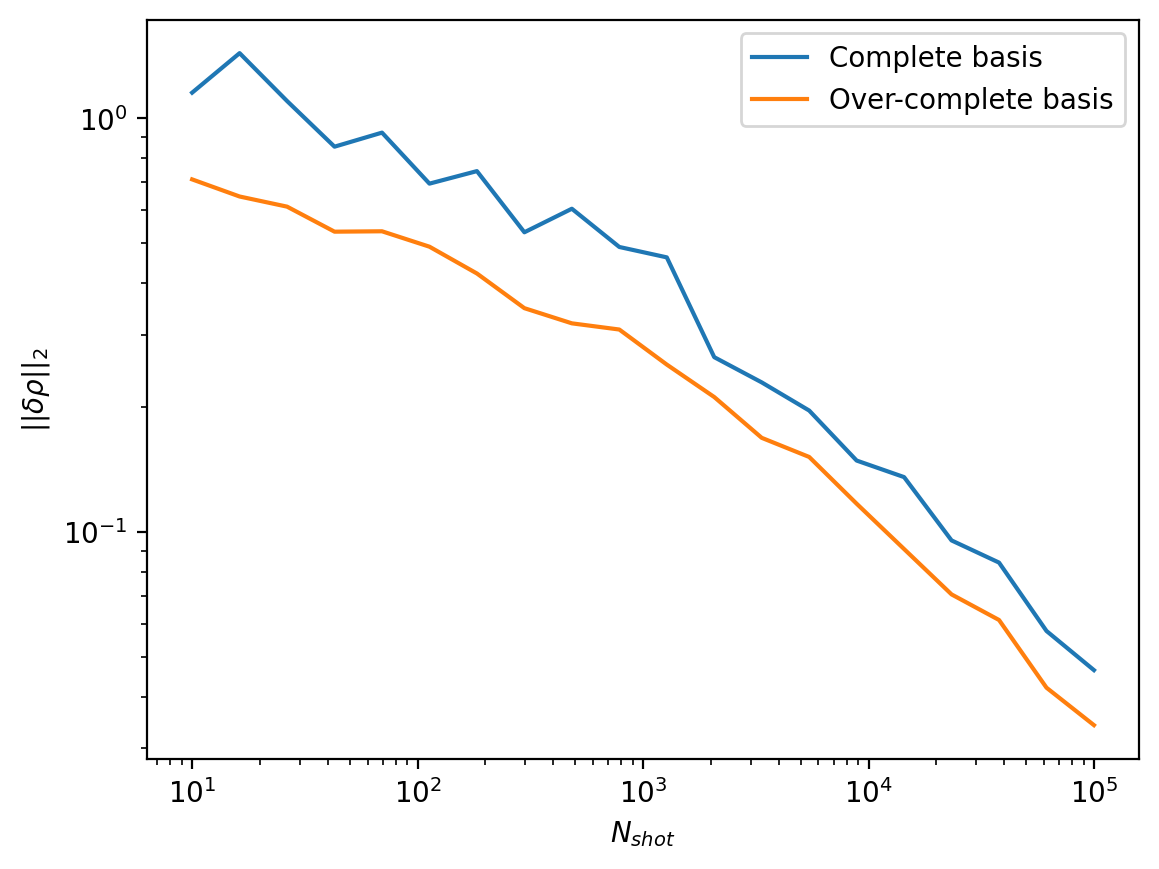

In [43]:
fig, ax = plt.subplots(dpi=200)
ax.plot(shots, np.array(norms))
ax.legend(['Complete basis', 'Over-complete basis'])
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$N_{shot}$')
ax.set_ylabel(r'$||\delta \rho||_2$')

Text(0, 0.5, '$MSE(\\mathcal{N})$')

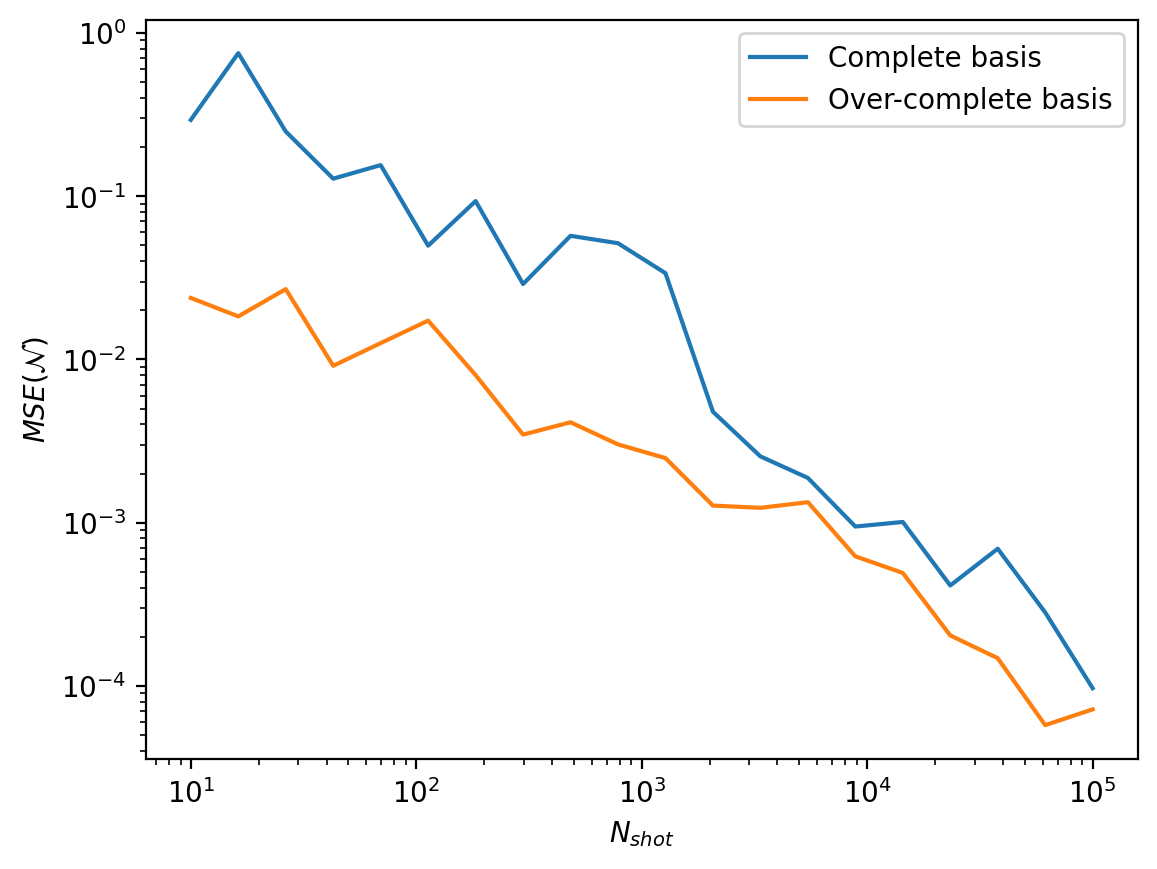

In [44]:
fig, ax = plt.subplots(dpi=200)
ax.plot(shots, np.array(neg_norms))
ax.legend(['Complete basis', 'Over-complete basis'])
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$N_{shot}$')
ax.set_ylabel(r'$MSE(\mathcal{N})$')